# SISEPUEDE Input File Explorer

This notebook helps you explore and understand the input CSV columns for SISEPUEDE Morocco calibration.

## How SISEPUEDE Variables Are Named

Every column follows a naming convention: `{prefix}_{subsector}_{details}_{unit_hints}`

### Subsector Prefixes (what sector the variable belongs to)

| Prefix | Subsector | Description |
|--------|-----------|-------------|
| `agrc` | Agriculture (Crops) | Crop areas, yields, residue fractions |
| `ccsq` | Carbon Capture | CCS sequestration |
| `entc` | Energy - Electricity | NemoMod power plant params (capacity, MSP, EAR, costs) |
| `enfu` | Energy - Fuels | Fuel emission factors, import fractions, exports |
| `fgtv` | Fugitive Emissions | Oil/gas/coal fugitive CH4, CO2, N2O |
| `frst` | Forestry | Forest climate fractions, carbon stocks |
| `gnrl` | General/Socioeconomic | Population, GDP, occupancy |
| `inen` | Industry Energy | Industrial energy intensity, fuel fractions by industry |
| `ippu` | Industrial Processes | Production volumes, process EFs, elasticities |
| `lndu` | Land Use | Markov transition probs (pij), reallocation factor (η), soil carbon |
| `lsmm` | Livestock Manure Mgmt | Manure MCFs, management system fractions |
| `lvst` | Livestock | Enteric fermentation EFs, populations, manure allocation |
| `scoe` | Stationary Comb. Other (Buildings) | Residential/commercial energy intensity, fuel fractions |
| `soil` | Soil Emissions | N2O emission factors (EF1, EF3, EF5), leaching |
| `trde` | Transport Demand | Passenger-km, tonne-km demand and elasticities |
| `trns` | Transport | Fuel efficiencies, mode shares, fuel mix |
| `trww` | Wastewater Treatment | Treatment fractions, MCFs, N2O EFs |
| `wali` | Wastewater (Liquid) | Domestic/industrial WW pathways |
| `waso` | Waste (Solid) | Waste generation, MCFs, composition |

### Common Variable Type Prefixes

| Type Prefix | Meaning | Example |
|-------------|---------|---------|
| `ef_` | Emission factor | `ef_lvst_entferm_cattle_dairy_kg_ch4_head` |
| `frac_` | Fraction (0-1) | `frac_inen_energy_cement_electricity` |
| `consumpinit_` | Initial consumption intensity | `consumpinit_scoe_gj_per_hh_heat_energy_residential` |
| `prodinit_` | Initial production volume | `prodinit_ippu_cement_tonne` |
| `elasticity_` | GDP/population elasticity | `elasticity_ippu_cement_production_to_gdp` |
| `nemomod_entc_` | NemoMod parameter | `nemomod_entc_residual_capacity_pp_coal_gw` |
| `pij_lndu_` | Land use transition probability | `pij_lndu_forests_secondary_to_croplands` |
| `mcf_` | Methane Correction Factor | `mcf_waso_average_landfilled` |
| `population_` | Population count | `population_gnrl_urban` |
| `gdp_` | GDP | `gdp_mmm_usd` |
| `deminit_` | Initial demand | `deminit_trde_pkm_per_capita_private_and_public` |
| `fuelefficiency_` | Fuel efficiency | `fuelefficiency_trns_road_light_diesel_km_per_litre` |
| `genfactor_` | Generation factor | `genfactor_lvst_daily_nitrogen_sheep` |
| `factor_` | Scaling factor | `factor_lndu_soil_carbon_croplands` |
| `qty_` | Quantity | `qty_waso_initial_municipal_waste_tonne_per_capita` |

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# === CONFIGURATION ===
PROJECT = Path("/Users/jrojasa/Documents/GitHub/ssp_morocco_calibration")
DEMO    = Path("/Users/jrojasa/Documents/GitHub/claude_ssp/ssp_morocco_demo")

# Load our file and the demo
df  = pd.read_csv(PROJECT / "ssp_modeling/input_data/df_input_0.csv")
demo = pd.read_csv(DEMO / "ssp_modeling/input_data/df_input_0.csv")

print(f"Morocco: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Demo:    {demo.shape[0]} rows x {demo.shape[1]} cols")
print(f"\nTime periods: {df['time_period'].min()} to {df['time_period'].max()} (years {2015+df['time_period'].min()}-{2015+df['time_period'].max()})")

Morocco: 36 rows x 2420 cols
Demo:    56 rows x 2420 cols

Time periods: 0 to 35 (years 2015-2050)


## Column Explorer — Search by keyword

In [2]:
def search_columns(keyword, show_values=True, tp=0):
    """Search for columns containing a keyword. Shows Morocco vs Demo values at given time period."""
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    print(f"Found {len(matches)} columns matching '{keyword}':\n")
    
    if show_values:
        rows = []
        for c in sorted(matches):
            m_val = df[df['time_period']==tp][c].values[0] if tp <= df['time_period'].max() else None
            d_val = demo[demo['time_period']==tp][c].values[0] if c in demo.columns and tp <= demo['time_period'].max() else None
            diff = ""
            if m_val is not None and d_val is not None and d_val != 0:
                pct = (m_val - d_val) / abs(d_val) * 100
                if abs(pct) > 1:
                    diff = f"{pct:+.1f}%"
            rows.append({"column": c, f"morocco_tp{tp}": m_val, f"demo_tp{tp}": d_val, "diff%": diff})
        
        result = pd.DataFrame(rows)
        with pd.option_context('display.max_colwidth', 80, 'display.max_rows', 100):
            display(result)
    else:
        for c in sorted(matches):
            print(f"  {c}")
    
    return matches

# Example: search for coal-related columns
search_columns("coal")

Found 89 columns matching 'coal':



,column,morocco_tp0,demo_tp0,diff%
0,cost_enfu_fuel_coal_usd_per_tonne,104.889167,104.889167,
1,ef_enfu_combustion_tonne_co2_per_tj_fuel_coal,97.016667,97.016667,
2,ef_enfu_combustion_tonne_co2_per_tj_fuel_coal_deposits,97.016667,97.016667,
3,ef_enfu_stationary_combustion_tonne_ch4_per_tj_fuel_coal,0.001000,0.001000,
4,ef_enfu_stationary_combustion_tonne_ch4_per_tj_fuel_coal_deposits,0.001000,0.001000,
5,ef_enfu_stationary_combustion_tonne_n2o_per_tj_fuel_coal,0.001500,0.001500,
6,ef_enfu_stationary_combustion_tonne_n2o_per_tj_fuel_coal_deposits,0.001500,0.001500,
7,ef_fgtv_production_flaring_tonne_ch4_per_m3_fuel_coal,0.000141,0.000141,
8,ef_fgtv_production_flaring_tonne_co2_per_m3_fuel_coal,0.051415,0.051415,
9,ef_fgtv_production_fugitive_tonne_ch4_per_m3_fuel_coal,0.000000,0.000000,


['nemomod_entc_residual_capacity_pp_coal_gw',
 'energydensity_enfu_mj_per_litre_fuel_coal',
 'ef_enfu_combustion_tonne_co2_per_tj_fuel_coal',
 'ef_enfu_combustion_tonne_co2_per_tj_fuel_coal_deposits',
 'ef_enfu_stationary_combustion_tonne_ch4_per_tj_fuel_coal',
 'ef_enfu_stationary_combustion_tonne_ch4_per_tj_fuel_coal_deposits',
 'energydensity_gravimetric_enfu_gj_per_tonne_fuel_coal',
 'ef_enfu_stationary_combustion_tonne_n2o_per_tj_fuel_coal',
 'ef_enfu_stationary_combustion_tonne_n2o_per_tj_fuel_coal_deposits',
 'cost_enfu_fuel_coal_usd_per_tonne',
 'ef_fgtv_production_flaring_tonne_ch4_per_m3_fuel_coal',
 'ef_fgtv_production_flaring_tonne_co2_per_m3_fuel_coal',
 'ef_fgtv_production_fugitive_tonne_ch4_per_m3_fuel_coal',
 'ef_fgtv_production_fugitive_tonne_co2_per_m3_fuel_coal',
 'ef_fgtv_production_venting_tonne_ch4_per_m3_fuel_coal',
 'ef_fgtv_production_venting_tonne_co2_per_m3_fuel_coal',
 'efficfactor_enfu_industrial_energy_fuel_coal',
 'efficfactor_entc_technology_fuel_use_pp_

## Column Inventory by Subsector

In [3]:
def column_inventory():
    """Count columns by subsector prefix."""
    prefixes = {}
    for c in df.columns:
        if c == 'time_period':
            continue
        # Extract subsector from naming convention
        parts = c.split('_')
        # Try to identify the subsector
        subsector_map = {
            'agrc': 'Agriculture/Crops', 'ccsq': 'Carbon Capture', 'ef': 'Emission Factors',
            'entc': 'Electricity (ENTC)', 'enfu': 'Energy Fuels', 'fgtv': 'Fugitive',
            'frst': 'Forestry', 'gnrl': 'Socioeconomic', 'inen': 'Industry Energy',
            'ippu': 'Industrial Processes', 'lndu': 'Land Use', 'lsmm': 'Livestock Manure',
            'lvst': 'Livestock', 'scoe': 'Buildings (SCOE)', 'soil': 'Soil N2O',
            'trde': 'Transport Demand', 'trns': 'Transport', 'trww': 'Wastewater Treatment',
            'wali': 'Wastewater Liquid', 'waso': 'Solid Waste', 'nemomod': 'NemoMod',
            'population': 'Population', 'gdp': 'GDP',
        }
        found = False
        for key, label in subsector_map.items():
            if key in c.lower():
                prefixes[label] = prefixes.get(label, 0) + 1
                found = True
                break
        if not found:
            prefixes['Other'] = prefixes.get('Other', 0) + 1
    
    inv = pd.DataFrame(sorted(prefixes.items(), key=lambda x: -x[1]), columns=['Subsector', 'Columns'])
    inv['%'] = (inv['Columns'] / inv['Columns'].sum() * 100).round(1)
    display(inv)
    print(f"\nTotal: {inv['Columns'].sum()} columns")

column_inventory()

,Subsector,Columns,%
0,Emission Factors,602,24.9
1,Industry Energy,315,13.0
2,Electricity (ENTC),284,11.7
3,Land Use,206,8.5
4,Agriculture/Crops,187,7.7
5,Livestock,182,7.5
6,Industrial Processes,110,4.5
7,Solid Waste,95,3.9
8,Energy Fuels,75,3.1
9,Transport,72,3.0



Total: 2419 columns


## Differences: Morocco vs Demo

Shows all columns where our file differs from the demo at tp=0 by more than a threshold.

In [4]:
def diff_morocco_vs_demo(min_pct=5, tp=0):
    """Find all columns where Morocco differs from Demo by more than min_pct% at given tp."""
    mar_row = df[df['time_period']==tp].iloc[0]
    demo_row = demo[demo['time_period']==tp].iloc[0]
    
    diffs = []
    for c in df.columns:
        if c == 'time_period' or c not in demo.columns:
            continue
        try:
            m, d = float(mar_row[c]), float(demo_row[c])
        except (ValueError, TypeError):
            continue
        if np.isnan(m) or np.isnan(d):
            continue
        if abs(d) > 1e-10:
            pct = (m - d) / abs(d) * 100
        elif abs(m) > 1e-10:
            pct = 999
        else:
            continue
        if abs(pct) >= min_pct:
            diffs.append({"column": c, "morocco": m, "demo": d, "diff_pct": round(pct, 1)})
    
    result = pd.DataFrame(diffs).sort_values("diff_pct", key=abs, ascending=False)
    print(f"Found {len(result)} columns differing by >{min_pct}% at tp={tp}")
    with pd.option_context('display.max_colwidth', 75, 'display.max_rows', 200):
        display(result.head(50))
    return result

diffs = diff_morocco_vs_demo(min_pct=10)

Found 96 columns differing by >10% at tp=0


,column,morocco,demo,diff_pct
5,frac_lvst_mm_cattle_nondairy_liquid_slurry,1.510965e-01,1.096491e-03,13680.0
6,frac_lvst_mm_cattle_nondairy_solid_storage,1.039474e-01,3.947368e-03,2533.3
4,frac_lvst_mm_cattle_dairy_liquid_slurry,2.704167e-01,2.041667e-02,1224.5
75,ef_ippu_tonne_sf6_per_tonne_production_electronics,2.481543e-08,0.000000e+00,999.0
91,ef_ippu_tonne_cf4_per_tonne_production_electronics,9.165732e-09,0.000000e+00,999.0
74,ef_ippu_tonne_nf3_per_tonne_production_electronics,1.470121e-09,0.000000e+00,999.0
76,ef_ippu_tonne_sf6_per_tonne_production_metals,1.550607e-07,0.000000e+00,999.0
82,ef_ippu_tonne_chf3_per_tonne_production_chemicals,6.721364e-07,0.000000e+00,999.0
83,ef_ippu_tonne_chf3_per_tonne_production_electronics,9.591872e-10,0.000000e+00,999.0
90,ef_ippu_tonne_c2f6_per_tonne_production_metals,6.551386e-08,0.000000e+00,999.0


## Time Series Viewer — Plot a column over time

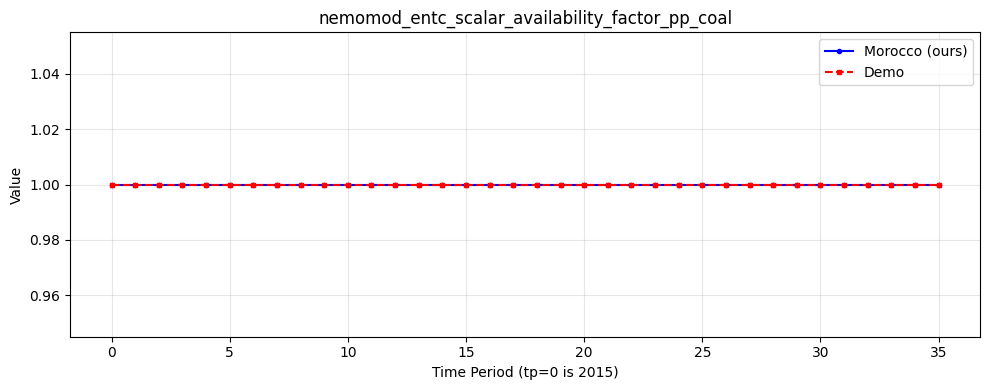

In [5]:
import matplotlib.pyplot as plt

def plot_column(col_name, compare_demo=True):
    """Plot a column over time, optionally comparing with demo."""
    fig, ax = plt.subplots(figsize=(10, 4))
    
    ax.plot(df['time_period'], df[col_name], 'b-o', markersize=3, label='Morocco (ours)')
    if compare_demo and col_name in demo.columns:
        ax.plot(demo['time_period'][:len(df)], demo[col_name][:len(df)], 'r--s', markersize=3, label='Demo')
    
    ax.set_xlabel('Time Period (tp=0 is 2015)')
    ax.set_ylabel('Value')
    ax.set_title(col_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example: plot coal availability factor
plot_column("nemomod_entc_scalar_availability_factor_pp_coal")

## Cross-Country Comparison

Compare a specific column across all available country files.

In [6]:
# Load other country files
country_files = {
    "Morocco": PROJECT / "ssp_modeling/input_data/df_input_0.csv",
    "Demo": DEMO / "ssp_modeling/input_data/df_input_0.csv",
    "Bulgaria": Path("/Users/jrojasa/Documents/GitHub/ssp_bulgaria/ssp_modeling/input_data/sisepuede_raw_inputs_latest_BGR.csv"),
    "Mexico": Path("/Users/jrojasa/Documents/GitHub/ssp_mexico/ssp_modeling/input_data/sisepuede_adj_inputs_MEX.csv"),
    "Peru": Path("/Users/jrojasa/Documents/GitHub/ssp_peru/ssp_modeling/input_data/inputs_lka_per_tza_built_20250225.csv"),
}

countries = {}
for name, path in country_files.items():
    try:
        countries[name] = pd.read_csv(path)
    except:
        print(f"Could not load {name}: {path}")

def compare_across_countries(col_name, tp=0):
    """Compare a column value at tp=0 across all countries."""
    rows = []
    for name, cdf in countries.items():
        if col_name in cdf.columns:
            if 'time_period' in cdf.columns:
                val = cdf[cdf['time_period']==tp][col_name].values
                val = val[0] if len(val) > 0 else None
            else:
                val = cdf[col_name].iloc[tp] if tp < len(cdf) else None
            rows.append({"country": name, "value": val})
    
    result = pd.DataFrame(rows)
    display(result)
    return result

# Example: compare coal EAR scalar
compare_across_countries("nemomod_entc_emissions_activity_ratio_scalar_pp_coal_co2")

,country,value
0,Morocco,1.0
1,Demo,1.0
2,Bulgaria,1.0
3,Mexico,1.0
4,Peru,1.0


,country,value
0,Morocco,1.0
1,Demo,1.0
2,Bulgaria,1.0
3,Mexico,1.0
4,Peru,1.0


## Quick Reference: Key Variables by Calibration Sector

Use `search_columns()` with these keywords to find relevant variables:

| Sector Gap | Search Keywords | Key Variables |
|-----------|----------------|---------------|
| ENTC CO2 (-67%) | `"availability_factor"`, `"min_share_production"`, `"residual_capacity"`, `"emissions_activity_ratio"` | MSP, capacity, EAR scalar |
| Transport CO2 (+11%) | `"fuelefficiency_trns"`, `"deminit_trde"`, `"elasticity_trde"`, `"frac_trns"` | Fuel efficiency, demand, mode shares |
| SCOE CO2 (+7%) | `"consumpinit_scoe"`, `"frac_scoe"`, `"efficfactor_scoe"` | Energy intensity, fuel mix |
| INEN CO2 (-1%) | `"consumpinit_inen"`, `"frac_inen"`, `"prodinit_ippu"` | Energy intensity, fuel mix, production |
| Waste CH4 (+2%) | `"mcf_waso"`, `"qty_waso"`, `"frac_waso"` | MCFs, waste/capita, composition |
| Livestock CH4 (-13%) | `"ef_lvst_entferm"`, `"population_lvst"` | Enteric EFs, populations |
| LSMM CH4 (-10%) | `"mcf_lsmm"`, `"frac_lvst_mm"` | Manure MCFs, management fractions |
| Soil N2O (+1%) | `"ef_soil"`, `"frac_soil"`, `"qty_soil"` | N2O EFs, leaching, fertilizer |
| IPPU CO2 (+14%) | `"prodinit_ippu"`, `"elasticity_ippu"`, `"ef_ippu"`, `"frac_ippu_cement"` | Production, elasticities, process EFs |
| Land Use | `"pij_lndu"`, `"frac_lndu"`, `"factor_lndu_soil_carbon"`, `"lndu_reallocation"` | Markov probs, initial fracs, η |

In [7]:
# Try it yourself! Uncomment and modify:
# search_columns("availability_factor")
# search_columns("cement")
# search_columns("entferm")
# plot_column("nemomod_entc_residual_capacity_pp_coal_gw")
# compare_across_countries("ef_lvst_entferm_cattle_nondairy_kg_ch4_head")

---

## ENTC CO2 Deep Dive: How Electricity Emissions Are Calculated

This section loads a model run output and traces exactly how ENTC CO2 emissions are computed, from inputs through to outputs.

In [8]:
# Load the latest run's WIDE_INPUTS_OUTPUTS (merged inputs + outputs)
import glob

run_dirs = sorted(glob.glob(str(PROJECT / "ssp_modeling/ssp_run_output/calibration_*")))
latest_run = run_dirs[-1]
print(f"Latest run: {latest_run}")

wide = pd.read_csv(f"{latest_run}/WIDE_INPUTS_OUTPUTS.csv")
print(f"WIDE shape: {wide.shape[0]} rows x {wide.shape[1]} cols")
print(f"  Input columns (in df_input_0.csv): {len([c for c in wide.columns if c in df.columns])}")
print(f"  Output columns (model-computed):    {len([c for c in wide.columns if c not in df.columns])}")
print(f"  emission_co2e_* output columns:     {len([c for c in wide.columns if c.startswith('emission_co2e_')])}")

Latest run: /Users/jrojasa/Documents/GitHub/ssp_morocco_calibration/ssp_modeling/ssp_run_output/calibration_20260305_125328
WIDE shape: 36 rows x 4054 cols
  Input columns (in df_input_0.csv): 2418
  Output columns (model-computed):    1636
  emission_co2e_* output columns:     611


In [9]:
# === ENTC CO2: Verify the emission formula using exact column names ===
#
# Formula: emission = fuel_EF × EAR_scalar × generation / 1000
#
# All column names shown are the actual names in the CSV / WIDE output.

tp = 7  # 2022

print(f"=== ENTC CO2 Verification at tp={tp} (year {2015+tp}) ===\n")

rows = []
for tech, fuel in [('coal', 'coal'), ('gas', 'natural_gas'), ('oil', 'oil')]:
    row = wide[wide['time_period']==tp].iloc[0]
    
    cols = {
        'generation_PJ':    f'nemomod_entc_annual_production_by_technology_pp_{tech}',
        'fuel_EF_tCO2_TJ':  f'ef_enfu_combustion_tonne_co2_per_tj_fuel_{fuel}',
        'EAR_scalar':        f'nemomod_entc_emissions_activity_ratio_scalar_pp_{tech}_co2',
        'emission_MtCO2e':   f'emission_co2e_co2_entc_generation_pp_{tech}',
        'capacity_GW':       f'nemomod_entc_residual_capacity_pp_{tech}_gw',
        'efficiency':        f'efficfactor_entc_technology_fuel_use_pp_{tech}',
    }
    
    vals = {k: row[c] if c in wide.columns else 0 for k, c in cols.items()}
    
    computed = vals['fuel_EF_tCO2_TJ'] * vals['EAR_scalar'] * vals['generation_PJ'] / 1000
    max_gen = vals['capacity_GW'] * 31.536
    utilization = vals['generation_PJ'] / max_gen * 100 if max_gen > 0 else 0
    
    vals['computed_MtCO2e'] = round(computed, 4)
    vals['match'] = abs(computed - vals['emission_MtCO2e']) < 0.001
    vals['utilization_%'] = round(utilization, 1)
    vals['tech'] = tech
    
    rows.append(vals)

result = pd.DataFrame(rows)
# Reorder columns to match the original table
result = result[['tech', 'generation_PJ', 'fuel_EF_tCO2_TJ', 'EAR_scalar', 'efficiency',
                 'emission_MtCO2e', 'computed_MtCO2e', 'match', 'capacity_GW', 'utilization_%']]
display(result)

print("\nColumn name mapping:")
for tech, fuel in [('coal', 'coal'), ('gas', 'natural_gas'), ('oil', 'oil')]:
    print(f"\n  {tech}:")
    print(f"    generation_PJ    = nemomod_entc_annual_production_by_technology_pp_{tech}         (OUTPUT)")
    print(f"    fuel_EF_tCO2_TJ  = ef_enfu_combustion_tonne_co2_per_tj_fuel_{fuel}              (INPUT)")
    print(f"    EAR_scalar       = nemomod_entc_emissions_activity_ratio_scalar_pp_{tech}_co2    (INPUT, clamped 0-1)")
    print(f"    efficiency       = efficfactor_entc_technology_fuel_use_pp_{tech}                (INPUT)")
    print(f"    emission_MtCO2e  = emission_co2e_co2_entc_generation_pp_{tech}                  (OUTPUT)")
    print(f"    capacity_GW      = nemomod_entc_residual_capacity_pp_{tech}_gw                  (INPUT)")

=== ENTC CO2 Verification at tp=7 (year 2022) ===



,tech,generation_PJ,fuel_EF_tCO2_TJ,EAR_scalar,efficiency,emission_MtCO2e,computed_MtCO2e,match,capacity_GW,utilization_%
0,coal,87.726759,97.016667,1.0,0.3,8.510958,8.5110,True,4.985000,55.8
1,gas,2.699285,56.100000,1.0,0.4,0.151430,0.1514,True,2.929245,2.9
2,oil,10.797140,75.350000,1.0,0.4,0.813564,0.8136,True,0.595000,57.5



Column name mapping:

  coal:
    generation_PJ    = nemomod_entc_annual_production_by_technology_pp_coal         (OUTPUT)
    fuel_EF_tCO2_TJ  = ef_enfu_combustion_tonne_co2_per_tj_fuel_coal              (INPUT)
    EAR_scalar       = nemomod_entc_emissions_activity_ratio_scalar_pp_coal_co2    (INPUT, clamped 0-1)
    efficiency       = efficfactor_entc_technology_fuel_use_pp_coal                (INPUT)
    emission_MtCO2e  = emission_co2e_co2_entc_generation_pp_coal                  (OUTPUT)
    capacity_GW      = nemomod_entc_residual_capacity_pp_coal_gw                  (INPUT)

  gas:
    generation_PJ    = nemomod_entc_annual_production_by_technology_pp_gas         (OUTPUT)
    fuel_EF_tCO2_TJ  = ef_enfu_combustion_tonne_co2_per_tj_fuel_natural_gas              (INPUT)
    EAR_scalar       = nemomod_entc_emissions_activity_ratio_scalar_pp_gas_co2    (INPUT, clamped 0-1)
    efficiency       = efficfactor_entc_technology_fuel_use_pp_gas                (INPUT)
    emission_MtCO2e 

In [10]:
# === ENTC: Show the actual INPUT columns that drive electricity emissions ===

print("=== INPUTS: Fuel Emission Factors (ef_enfu_combustion_tonne_co2_per_tj_fuel_*) ===\n")
ef_cols = [c for c in df.columns if c.startswith('ef_enfu_combustion_tonne_co2_per_tj_fuel_')]
for c in sorted(ef_cols):
    print(f"  {c:<60s} = {df[c].iloc[0]:.4f}")

print("\n=== INPUTS: Technology Efficiency (efficfactor_entc_technology_fuel_use_pp_*) ===\n")
eff_cols = [c for c in df.columns if c.startswith('efficfactor_entc_technology_fuel_use_')]
for c in sorted(eff_cols):
    v = df[c].iloc[0]
    if v > 0.001:
        print(f"  {c:<60s} = {v:.4f}")

print("\n=== INPUTS: EAR Scalars (nemomod_entc_emissions_activity_ratio_scalar_pp_*_co2) ===\n")
ear_cols = [c for c in df.columns if 'emissions_activity_ratio_scalar' in c and '_co2' in c]
for c in sorted(ear_cols):
    print(f"  {c:<75s} = {df[c].iloc[0]:.4f}")

print("\n=== INPUTS: Residual Capacity (nemomod_entc_residual_capacity_pp_*_gw) ===\n")
cap_cols = [c for c in df.columns if 'residual_capacity_pp_' in c and '_gw' in c]
for c in sorted(cap_cols):
    v = df[c].iloc[0]
    if v > 0.0001:
        print(f"  {c:<60s} = {v:.4f} GW")

print("\n=== INPUTS: Min Share Production / MSP (nemomod_entc_frac_min_share_production_pp_*) ===\n")
msp_cols = [c for c in df.columns if 'frac_min_share_production_pp_' in c]
for c in sorted(msp_cols):
    v = df[c].iloc[0]
    if v > 0.0001:
        print(f"  {c:<60s} = {v:.4f}")

print("\n=== INPUTS: Availability Factor (nemomod_entc_scalar_availability_factor_pp_*) ===\n")
af_cols = [c for c in df.columns if 'scalar_availability_factor_pp_' in c]
for c in sorted(af_cols):
    print(f"  {c:<60s} = {df[c].iloc[0]:.4f}")

=== INPUTS: Fuel Emission Factors (ef_enfu_combustion_tonne_co2_per_tj_fuel_*) ===

  ef_enfu_combustion_tonne_co2_per_tj_fuel_ammonia             = 0.0000
  ef_enfu_combustion_tonne_co2_per_tj_fuel_biofuels            = 73.7333
  ef_enfu_combustion_tonne_co2_per_tj_fuel_biogas              = 54.6000
  ef_enfu_combustion_tonne_co2_per_tj_fuel_biomass             = 103.3250
  ef_enfu_combustion_tonne_co2_per_tj_fuel_coal                = 97.0167
  ef_enfu_combustion_tonne_co2_per_tj_fuel_coal_deposits       = 97.0167
  ef_enfu_combustion_tonne_co2_per_tj_fuel_coke                = 103.8333
  ef_enfu_combustion_tonne_co2_per_tj_fuel_crude               = 73.3000
  ef_enfu_combustion_tonne_co2_per_tj_fuel_diesel              = 74.1000
  ef_enfu_combustion_tonne_co2_per_tj_fuel_electricity         = 0.0000
  ef_enfu_combustion_tonne_co2_per_tj_fuel_furnace_gas         = 221.0000
  ef_enfu_combustion_tonne_co2_per_tj_fuel_gasoline            = 69.7667
  ef_enfu_combustion_tonne_co2_per_tj_f

In [11]:
# === OUTPUTS: What NemoMod computed (from WIDE_INPUTS_OUTPUTS.csv) ===

print("=== OUTPUTS: Coal generation and emissions by time period ===\n")
print(f"{'tp':>3s} {'Year':>5s}  {'generation_PJ':>14s}  {'residual_cap_GW':>16s}  {'total_cap_GW':>13s}  {'emission_MtCO2e':>16s}")
print("-" * 75)

for tp in range(0, 36):
    row = wide[wide['time_period']==tp].iloc[0]
    gen = row['nemomod_entc_annual_production_by_technology_pp_coal']
    cap = row['nemomod_entc_residual_capacity_pp_coal_gw']
    total_cap = row['nemomod_entc_total_annual_generation_capacity_pp_coal']
    em = row['emission_co2e_co2_entc_generation_pp_coal']
    print(f"{tp:>3d} {2015+tp:>5d}  {gen:>14.2f}  {cap:>16.3f}  {total_cap:>13.3f}  {em:>16.6f}")

print("\n=== OUTPUTS: ALL ENTC CO2 by technology at tp=7 ===\n")
row7 = wide[wide['time_period']==7].iloc[0]
entc_co2_cols = sorted([c for c in wide.columns if c.startswith('emission_co2e_co2_entc_generation_pp_')])
total = 0
for c in entc_co2_cols:
    v = row7[c]
    if abs(v) > 0.0001:
        print(f"  {c:<60s} = {v:.6f} MtCO2e")
        total += v
print(f"\n  {'TOTAL':<60s} = {total:.6f} MtCO2e")
print(f"  {'SNBC TARGET':<60s} = 29.0 MtCO2e")

=== OUTPUTS: Coal generation and emissions by time period ===

 tp  Year   generation_PJ   residual_cap_GW   total_cap_GW   emission_MtCO2e
---------------------------------------------------------------------------
  0  2015           77.75             4.985          4.985          7.543423
  1  2016           78.19             4.985          4.985          7.585568
  2  2017           78.39             4.985          4.985          7.605458
  3  2018           81.49             4.985          4.985          7.905653
  4  2019           83.89             4.985          4.985          8.138879
  5  2020           83.76             4.985          4.985          8.126341
  6  2021           88.66             4.985          4.985          8.601803
  7  2022           87.73             4.985          4.985          8.510958
  8  2023          125.92             4.985          4.988         12.216718
  9  2024          127.60             4.985          5.054         12.379677
 10  2025     

## Experiment: Does changing coal efficiency affect ENTC CO2?

Two runs were compared:
- **Run A** (baseline): `efficfactor_entc_technology_fuel_use_pp_coal = 0.45`
- **Run B** (lower efficiency): `efficfactor_entc_technology_fuel_use_pp_coal = 0.30`

In [12]:
# Load both runs
run_eff045 = pd.read_csv(PROJECT / "ssp_modeling/ssp_run_output/calibration_20260305_123732/WIDE_INPUTS_OUTPUTS.csv")
run_eff030 = pd.read_csv(PROJECT / "ssp_modeling/ssp_run_output/calibration_20260305_125328/WIDE_INPUTS_OUTPUTS.csv")

tp = 7
r1 = run_eff045[run_eff045['time_period']==tp].iloc[0]
r2 = run_eff030[run_eff030['time_period']==tp].iloc[0]

# The columns that matter
cols = {
    "INPUT: efficfactor_entc_technology_fuel_use_pp_coal":        "efficfactor_entc_technology_fuel_use_pp_coal",
    "INPUT: ef_enfu_combustion_tonne_co2_per_tj_fuel_coal":       "ef_enfu_combustion_tonne_co2_per_tj_fuel_coal",
    "INPUT: nemomod_entc_emissions_activity_ratio_scalar_pp_coal_co2": "nemomod_entc_emissions_activity_ratio_scalar_pp_coal_co2",
    "OUTPUT: nemomod_entc_annual_production_by_technology_pp_coal (PJ elec)": "nemomod_entc_annual_production_by_technology_pp_coal",
    "OUTPUT: energy_demand_enfu_subsector_total_pj_entc_fuel_coal (PJ fuel)": "energy_demand_enfu_subsector_total_pj_entc_fuel_coal",
    "OUTPUT: totalvalue_enfu_fuel_consumed_entc_fuel_coal":       "totalvalue_enfu_fuel_consumed_entc_fuel_coal",
    "OUTPUT: emission_co2e_co2_entc_generation_pp_coal (MtCO2e)": "emission_co2e_co2_entc_generation_pp_coal",
}

rows = []
for label, col in cols.items():
    v1 = r1[col]
    v2 = r2[col]
    rows.append({"column": label, "eff=0.45": round(v1, 4), "eff=0.30": round(v2, 4), "changed?": "YES" if abs(v2-v1) > 0.001 else "no"})

result = pd.DataFrame(rows)
with pd.option_context('display.max_colwidth', 80):
    display(result)

print("""
WHAT HAPPENED:
  - NemoMod burned 50% more coal (195 → 292 PJ of fuel)
  - But electricity OUTPUT stayed the same (87.7 PJ both ways)
  - ENTC CO2 = fuel_EF × EAR_scalar × electricity_OUTPUT / 1000
  - Since fuel_EF, EAR_scalar, and electricity_OUTPUT all stayed the same,
    emissions stayed at 8.511 MtCO2e regardless of efficiency

WHY:
  - SISEPUEDE computes emissions from ELECTRICITY OUTPUT, not FUEL BURNED
  - The efficiency only tells NemoMod how much fuel to procure
  - The emission formula never looks at actual fuel consumption
""")

,column,eff=0.45,eff=0.30,changed?
0,INPUT: efficfactor_entc_technology_fuel_use_pp_coal,0.4500,0.3000,YES
1,INPUT: ef_enfu_combustion_tonne_co2_per_tj_fuel_coal,97.0167,97.0167,no
2,INPUT: nemomod_entc_emissions_activity_ratio_scalar_pp_coal_co2,1.0000,1.0000,no
3,OUTPUT: nemomod_entc_annual_production_by_technology_pp_coal (PJ elec),87.7268,87.7268,no
4,OUTPUT: energy_demand_enfu_subsector_total_pj_entc_fuel_coal (PJ fuel),194.9484,292.4225,YES
5,OUTPUT: totalvalue_enfu_fuel_consumed_entc_fuel_coal,737.6613,1106.4919,YES
6,OUTPUT: emission_co2e_co2_entc_generation_pp_coal (MtCO2e),8.5110,8.5110,no



WHAT HAPPENED:
  - NemoMod burned 50% more coal (195 → 292 PJ of fuel)
  - But electricity OUTPUT stayed the same (87.7 PJ both ways)
  - ENTC CO2 = fuel_EF × EAR_scalar × electricity_OUTPUT / 1000
  - Since fuel_EF, EAR_scalar, and electricity_OUTPUT all stayed the same,
    emissions stayed at 8.511 MtCO2e regardless of efficiency

WHY:
  - SISEPUEDE computes emissions from ELECTRICITY OUTPUT, not FUEL BURNED
  - The efficiency only tells NemoMod how much fuel to procure
  - The emission formula never looks at actual fuel consumption



## Bug Fix: Array Mutation in SISEPUEDE (commit `e9f27d4`)

The old SISEPUEDE version (commit `543da2f`) had a critical bug: `arr_enfu_production += arr_enfu_imports` mutated a shared tuple reference in-place. Called in 2 methods, imports were added to production **twice**, creating phantom electricity exports (~18 PJ). The new version (`90e903f`) copies the array first.

Impact: Old version inflated ENTC CO2 by ~1.4 MtCO2e. New version is correct.

In [ ]:
# Compare old (buggy) vs new (fixed) version outputs
old_buggy = pd.read_csv(PROJECT / "ssp_modeling/ssp_run_output/calibration_20260305_123732/WIDE_INPUTS_OUTPUTS.csv")
new_fixed = pd.read_csv(PROJECT / "ssp_modeling/ssp_run_output/calibration_20260305_131859/WIDE_INPUTS_OUTPUTS.csv")

tp = 7
ob = old_buggy[old_buggy['time_period']==tp].iloc[0]
nf = new_fixed[new_fixed['time_period']==tp].iloc[0]

bug_cols = {
    "OUTPUT: nemomod_entc_annual_production_by_technology_pp_coal (PJ elec)":
        "nemomod_entc_annual_production_by_technology_pp_coal",
    "OUTPUT: energy_demand_enfu_subsector_total_pj_entc_fuel_coal (PJ fuel)":
        "energy_demand_enfu_subsector_total_pj_entc_fuel_coal",
    "OUTPUT: emission_co2e_co2_entc_generation_pp_coal (MtCO2e)":
        "emission_co2e_co2_entc_generation_pp_coal",
    "OUTPUT: emission_co2e_co2_entc_generation_for_export (MtCO2e)":
        "emission_co2e_co2_entc_generation_for_export",
    "OUTPUT: emission_co2e_subsector_total_entc (MtCO2e)":
        "emission_co2e_subsector_total_entc",
    "INPUT:  exports_enfu_pj_fuel_electricity (PJ specified)":
        "exports_enfu_pj_fuel_electricity",
}

rows = []
for label, col in bug_cols.items():
    v1 = ob[col] if col in ob.index else 0
    v2 = nf[col] if col in nf.index else 0
    rows.append({"column": label, "old_buggy": round(v1, 4), "new_fixed": round(v2, 4),
                 "delta": round(v2 - v1, 4)})

display(pd.DataFrame(rows))

print("""
The old version generated 18.5 PJ of phantom electricity exports due to
double-counting fuel imports in the production estimate. The new version
correctly exports only 0.49 PJ (matching the input value of 0.486 PJ).
This reduced total ENTC CO2 from 9.49 to 8.10 MtCO2e.
""")

## Calibration Progress: 53.15 → 12.29 MtCO2e (-76.9%)

In [ ]:
# Load best run results
best_run = pd.read_csv(PROJECT / "ssp_modeling/ssp_run_output/calibration_20260306_162617/diff_report_morocco_ndc.csv")

# Show calibrated sectors
rows = []
for _, row in best_run.iterrows():
    t = row['edgar_MtCO2e']
    m = row['ssp_MtCO2e']
    if t != 0 and abs(m) > 0.01:
        gap = m - t
        err = gap / abs(t) * 100
        status = '<=15%' if abs(err) <= 15 else '<=25%' if abs(err) <= 25 else '>25%'
        rows.append({
            'category': row['category'],
            'target_MtCO2e': round(t, 2),
            'model_MtCO2e': round(m, 2),
            'gap_MtCO2e': round(gap, 2),
            'error_%': round(err, 1),
            'status': status,
        })

result = pd.DataFrame(rows).sort_values('error_%', key=abs)
with pd.option_context('display.max_colwidth', 55, 'display.max_rows', 40):
    display(result)

n15 = sum(1 for r in rows if r['status'] == '<=15%')
n25 = sum(1 for r in rows if r['status'] in ['<=15%', '<=25%'])
print(f"\nSectors <=15%: {n15}")
print(f"Sectors <=25%: {n25}")
print(f"NDC error: 12.29 MtCO2e")

In [ ]:
# Key parameter changes and their sources
changes = pd.DataFrame([
    ("efficfactor_entc_technology_fuel_use_pp_coal", "0.45", "0.36", "SNBC grid EF 730 gCO2/kWh back-calculation"),
    ("efficfactor_entc_technology_fuel_use_pp_oil", "0.40", "0.35", "IEA Electricity Info: developing-country oil plants"),
    ("efficfactor_entc_technology_fuel_use_pp_gas", "0.40", "0.37", "IEA: aging CCGT + open-cycle peakers"),
    ("frac_inen_energy_mining_natural_gas", "0.57", "0.02", "IEA Industry TFC: Morocco NG = 1.9% of industry"),
    ("frac_inen_energy_mining_electricity", "0.16", "0.50", "OCP phosphate mining electrified operations"),
    ("frac_inen_energy_cement_electricity", "0.18", "0.30", "IEA: cement grinding is electrified"),
    ("frac_inen_energy_paper_natural_gas", "0.20", "0.02", "IEA: Morocco minimal NG infrastructure"),
    ("consumpinit_scoe_gj_per_hh_residential_elec_appliances", "5.34", "5.57", "IEA 2022: 44,564 TJ / 7.37M HH"),
    ("ef_lvst_entferm_sheep_kg_ch4_head", "5", "6", "IPCC 2006 Table 10.10 + weight scaling (55kg vs 45kg)"),
    ("ef_lvst_entferm_goats_kg_ch4_head", "5", "5.5", "IPCC 2006 Table 10.10, Morocco feed quality"),
    ("frac_ippu_cement_clinker", "0.72", "0.68", "SNBC: CEM II/B adoption (65-70% clinker)"),
    ("elasticity_ippu_cement_production_to_gdp", "0.10", "0.0", "SNBC: cement market saturated post-2020"),
    ("mcf_lsmm_liquid_slurry", "0.37", "0.47", "IPCC 2006 Vol.4 Table 10.17, ~18C warm climate"),
    ("ef_trww_treated_secondary_aerobic_g_n2o_per_g_n", "0.016", "0.005", "IPCC 2006 Table 6.8 (BUR3 methodology)"),
    ("pij_lndu_*_to_wetlands (4 cols)", ">0", "0", "Morocco semi-arid, Ramsar wetlands stable"),
    ("frac_lvst_mm_sheep_paddock_pasture_range", "0.95", "0.75", "Morocco Eid fattening, partial confinement"),
    ("lndu_reallocation_factor (eta)", "0.10", "0.25", "Optimized via sweep (0.05-0.40)"),
], columns=["parameter", "old", "new", "source"])

with pd.option_context('display.max_colwidth', 60, 'display.max_rows', 30):
    display(changes)